In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Flow Examples (Stokes Equations Solutions)</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

---

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Exchanger Device</h3>
</div>

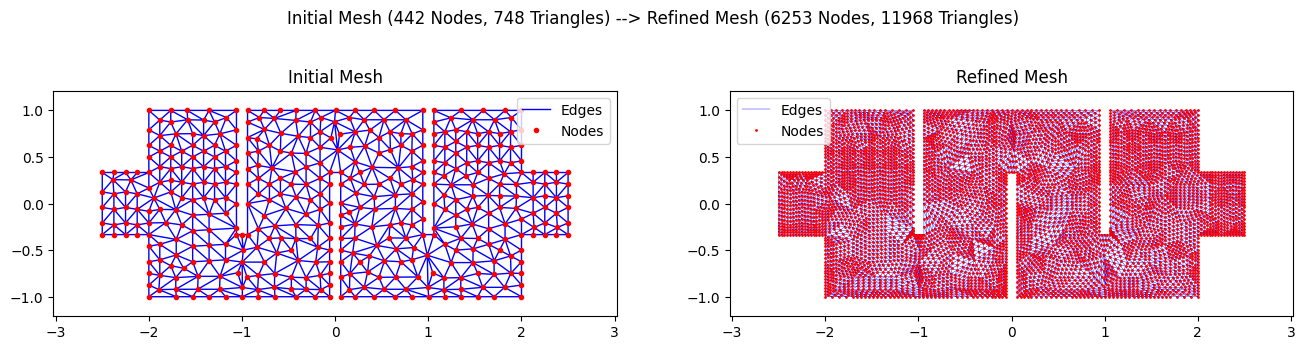

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=2, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [5]:
p_fine, e_fine, t_fine, p_coarse, e_coarse, t_coarse, ux, uy, p_sol = load_simulation_data("Solutions/Exchanger_device.npz")

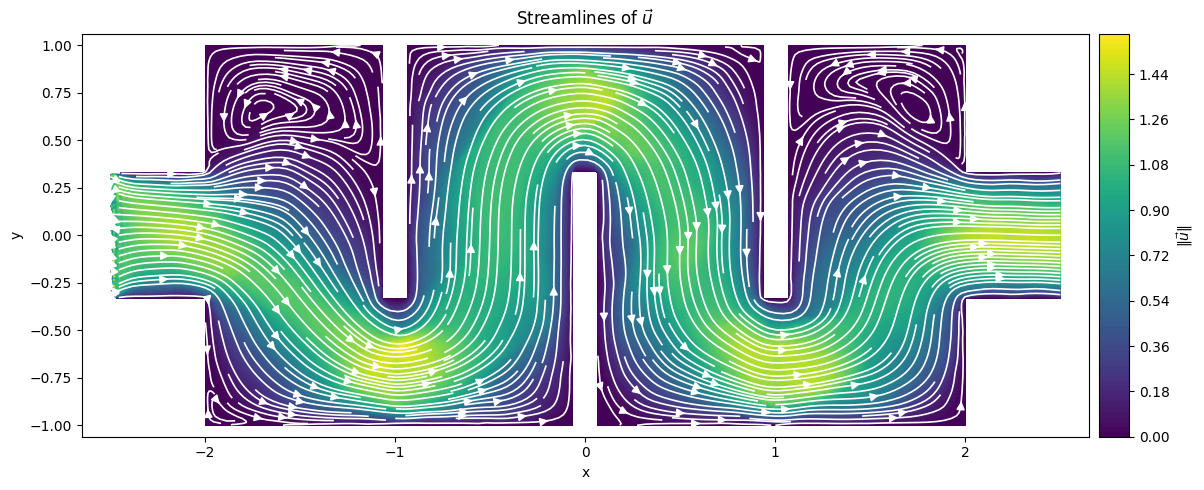

In [6]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 grid_num=(500,500),
                 figsize=(15,5),
                 density=3.7)

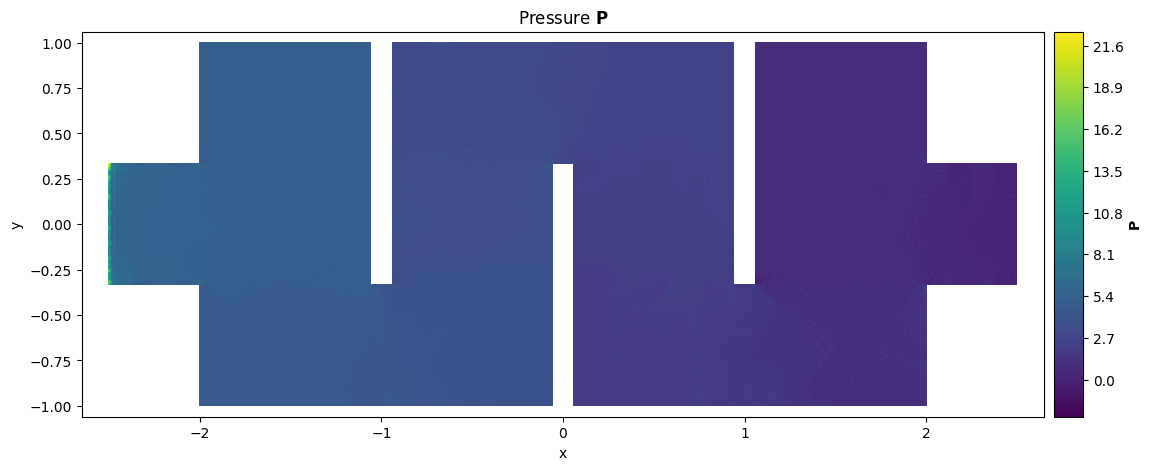

In [7]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Laminar Flow Past a Backstep</h3>
</div>

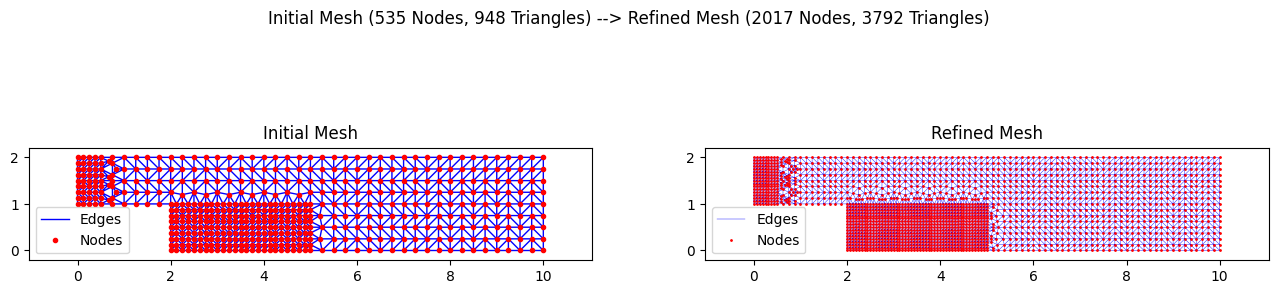

In [9]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/Backstep_mesh_data.npz', num_of_refinements=1, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [10]:
p_fine, e_fine, t_fine, p_coarse, e_coarse, t_coarse, ux, uy, p_sol = load_simulation_data("Solutions/Backstep.npz")

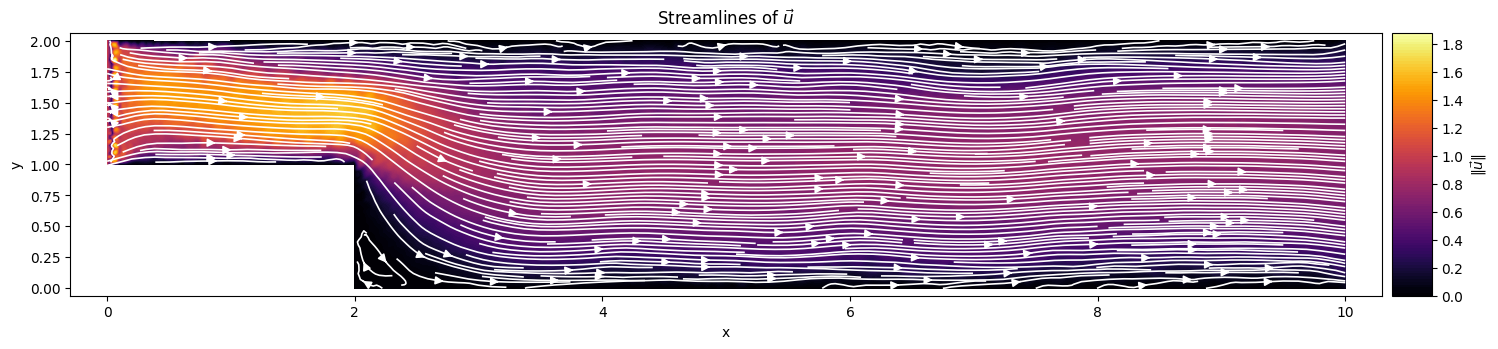

In [11]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 figsize=(15,5),
                 cmap='inferno',
                 levels=100,
                 grid_num=(1500,500),
                 density=2.7)

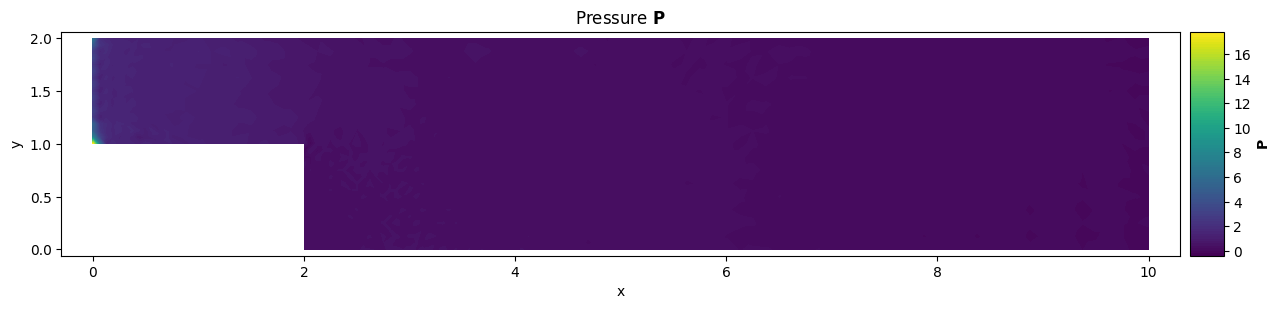

In [12]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Comb Vortices</h3>
</div>

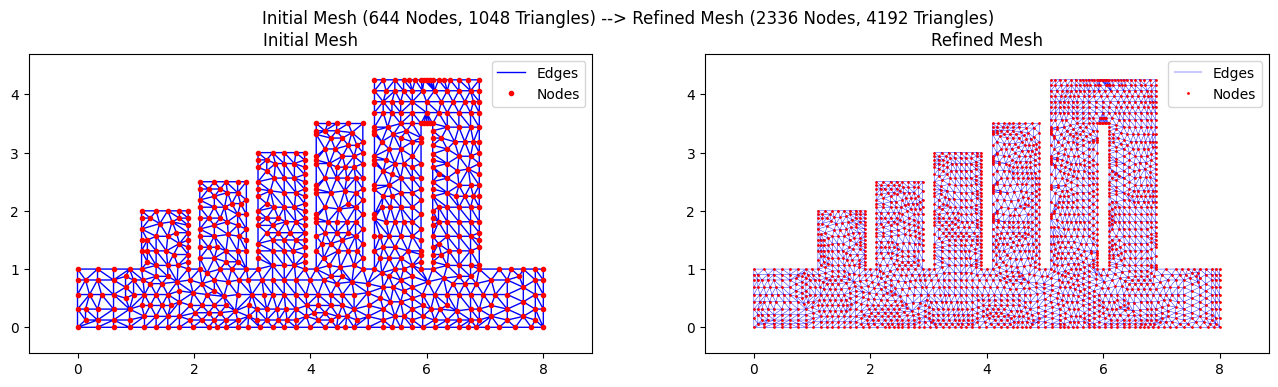

In [14]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/Comb_mesh_data.npz', num_of_refinements=1, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [13]:
p_fine, e_fine, t_fine, p_coarse, e_coarse, t_coarse, ux, uy, p_sol = load_simulation_data("Solutions/Comb.npz")

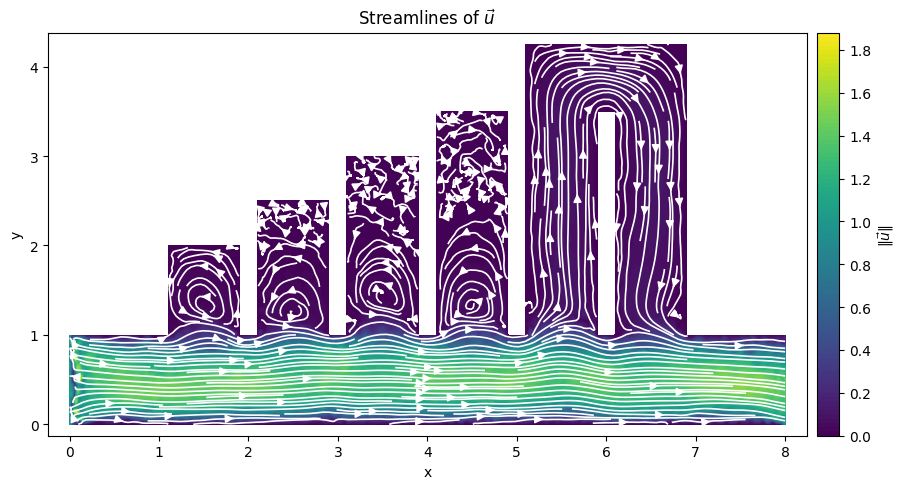

In [14]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 figsize=(15,5),
                 cmap='viridis',
                 levels=100,
                 grid_num=(1500,1500),
                 density=3.7)

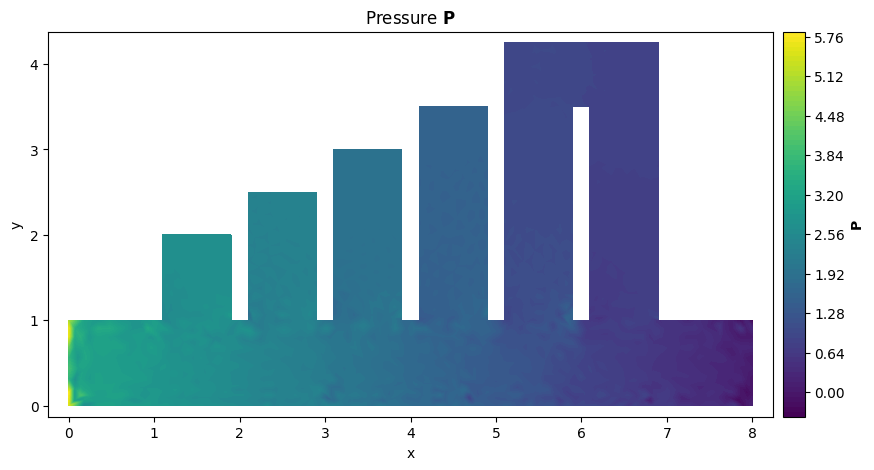

In [15]:
plot_pressure(p_coarse, t_coarse, p_sol,
              levels=100,
              figsize=(15,5))

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Hexagonal Pipe System</h3>
</div>

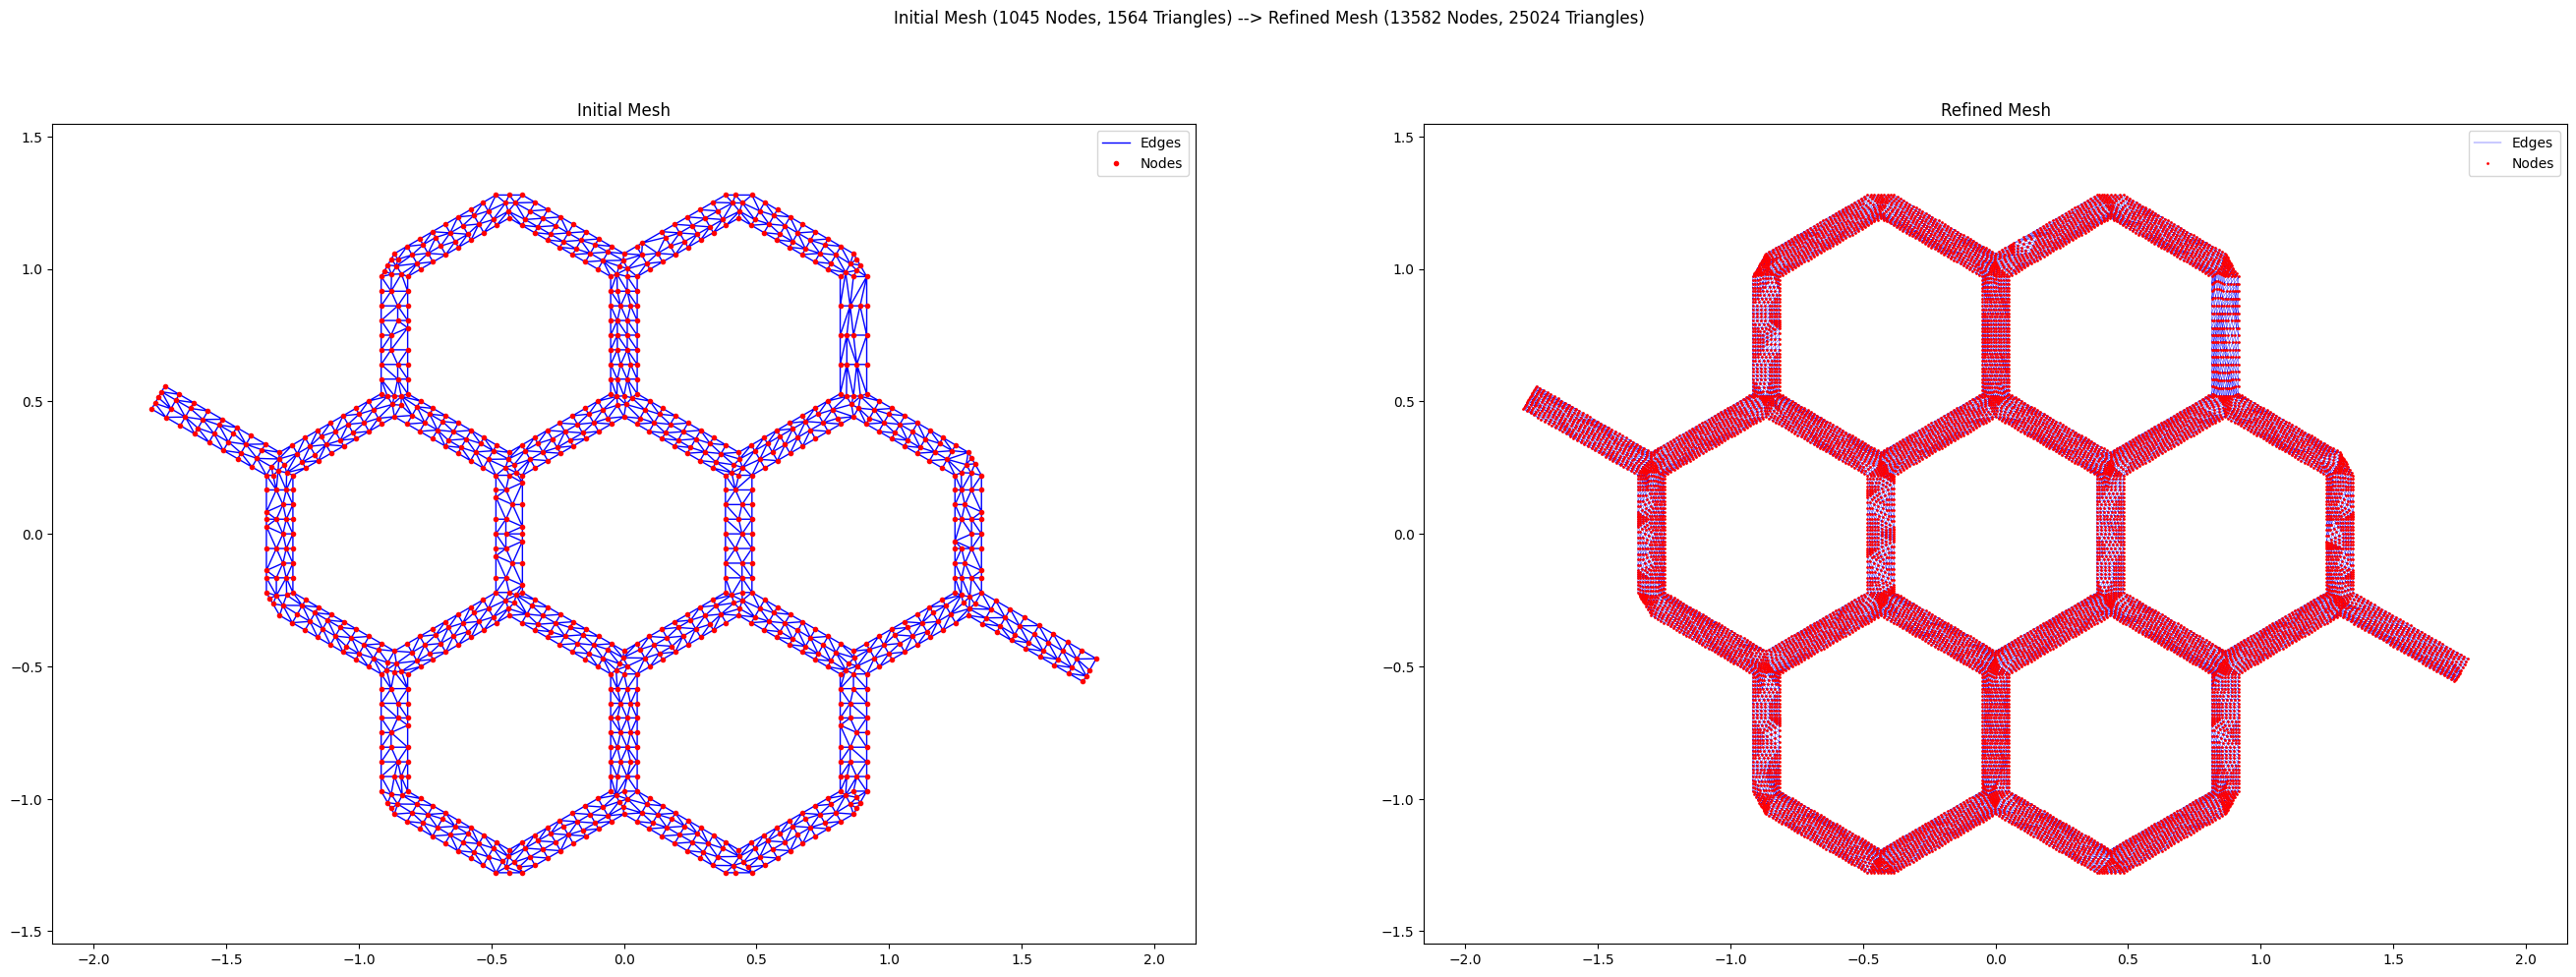

In [35]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/Hexagonal_pipe_system_mesh_data.npz', num_of_refinements=2, 
                                                           figsize=(33,11))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

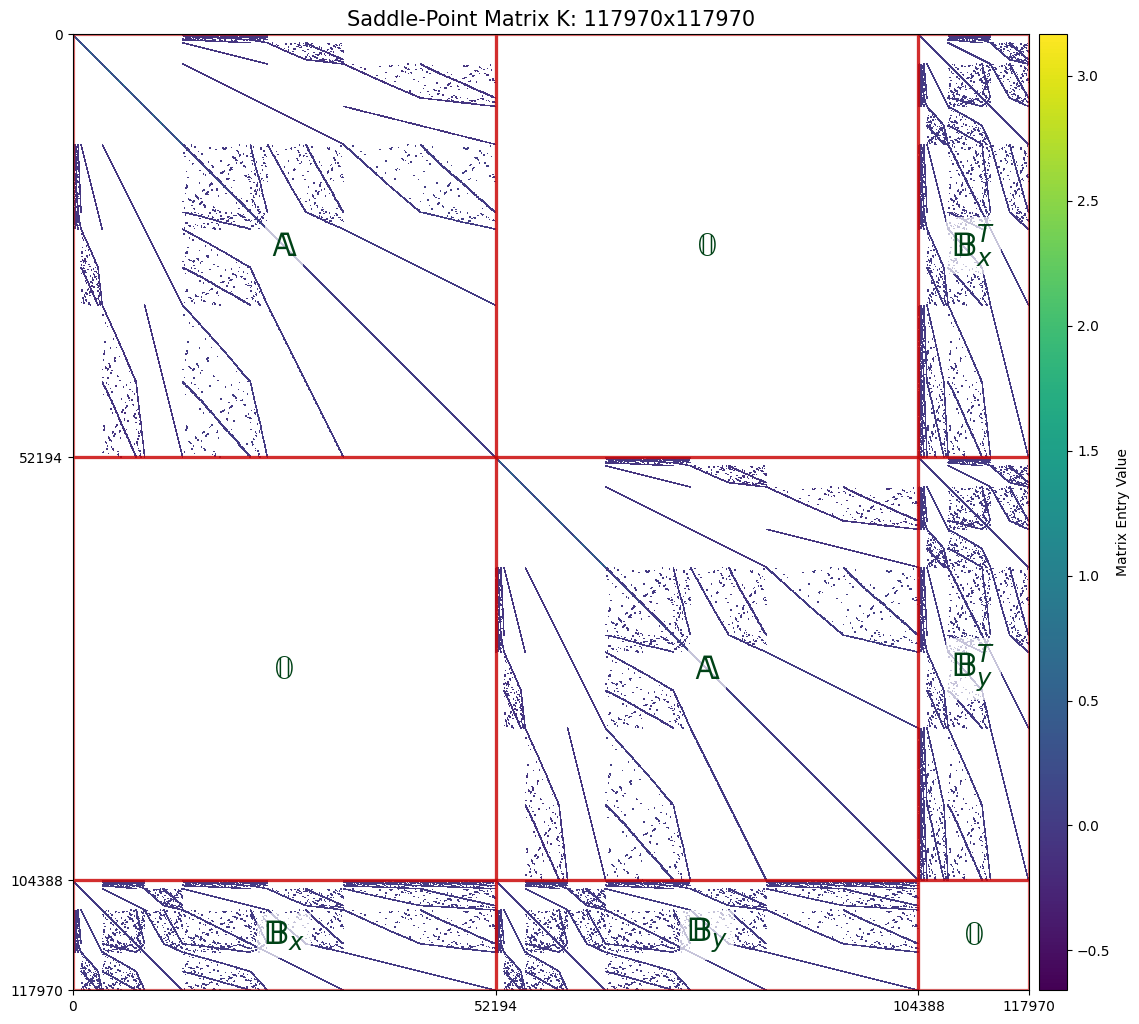

In [39]:
A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=0.01)
B_x, B_y = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
K = calculate_Saddle_point_K(A, B_x, B_y)
K_matrix_structure(K, A.shape[0], B_x.shape[0], (11.5,11.5))

In [27]:
def compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse):
    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-4  # Practical tolerance for geometric matching

    # Define your exact boundary coordinates
    inlet_A = np.array([-1.78205, 0.471132])
    inlet_B = np.array([-1.73205, 0.557735])
    
    exit_A  = np.array([1.73205, -0.557735])
    exit_B  = np.array([1.78205, -0.471133])

    # --- Helper function to find nodes on a specific line segment ---
    def find_nodes_on_segment(nodes, A, B, tol):
        # Vector along the segment
        AB = B - A
        ab_len_sq = np.dot(AB, AB)
        
        indices = []
        for idx, P in enumerate(nodes):
            # Project point P onto infinite line AB
            t = np.dot(P - A, AB) / ab_len_sq
            if 0.0 - tol <= t <= 1.0 + tol:  # Check if projection falls within segment bounds
                # Calculate perpendicular distance to the line
                projection = A + t * AB
                dist = np.linalg.norm(P - projection)
                if dist < tol:
                    indices.append(idx)
        return np.array(indices, dtype=int)

    # Cleanly locate your rotated boundaries
    inlet_idx  = find_nodes_on_segment(p_fine, inlet_A, inlet_B, eps)
    outlet_idx = find_nodes_on_segment(p_fine, exit_A,  exit_B,  eps)

    # Isolate remaining solid wall nodes
    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))

    # --- Construct the lifting functions matching the 120-degree orientation ---
    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    
    # Apply your flow entering cleanly at 120 degrees across the newly located slanted nodes
    lf_x[inlet_idx] = -0.866025
    lf_y[inlet_idx] = -0.5

    # Run your standard FE matrix assembly operators
    A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=0.01)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    
    F = calculate_F(A, Bx, By, (lf_x, lf_y))
    K = calculate_Saddle_point_K(A, Bx, By).tolil()

    # Apply 0.0 Dirichlet constraints to solid boundaries
    for i in v_wall_idx:
        K[i, :] = 0.0
        K[i, i] = 1.0
        F[i] = 0.0  

        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy] = 0.0  

    # Pin homogeneous component u0 to 0 on the inlet nodes
    for i in inlet_idx:
        K[i, :] = 0.0
        K[i, i] = 1.0
        F[i] = 0.0  

        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy] = 0.0  

    # Fix pressure reference using the coarse nodes found near the exit segment
    p_outlet_idx = find_nodes_on_segment(p_coarse, exit_A, exit_B, eps)
    p_ref = p_outlet_idx[0]
    p_row = 2 * Nv + p_ref

    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0

    print(f"Solving system with {len(inlet_idx)} inlet nodes and {len(outlet_idx)} outlet nodes...")
    sol = spsolve(K.tocsc(), F)

    u0_x = sol[:Nv]
    u0_y = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    # Recombine to recover complete velocity profiles
    ux = u0_x + lf_x
    uy = u0_y + lf_y

    return ux, uy, pressure

In [36]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse)

Solving system with 33 inlet nodes and 25 outlet nodes...


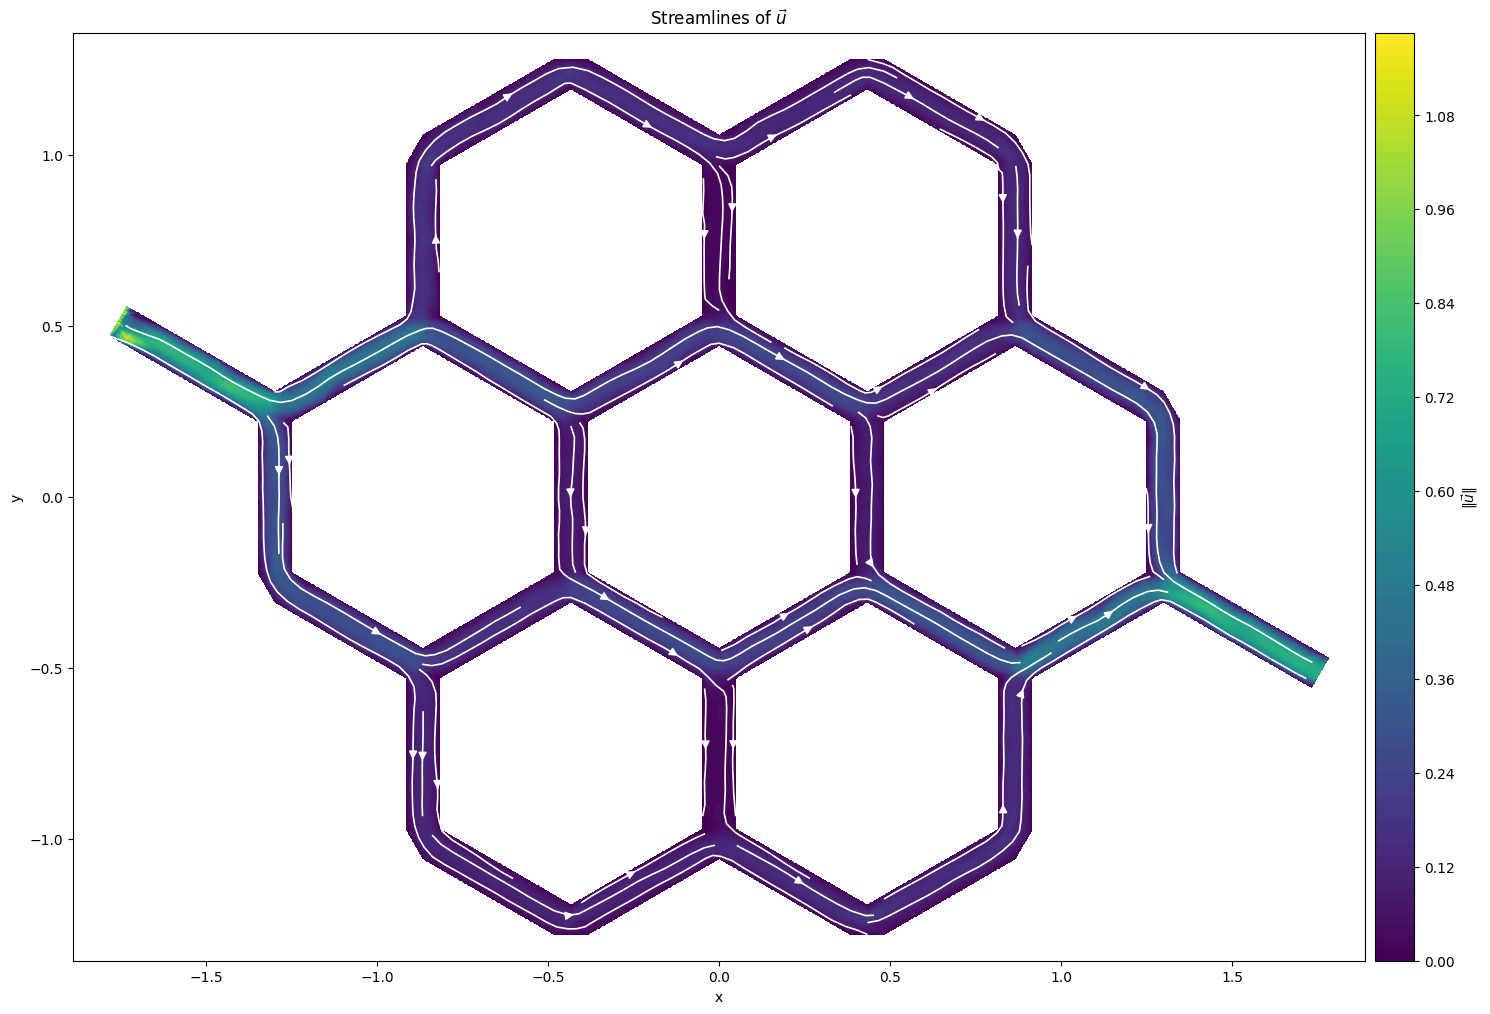

In [37]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 figsize=(15,15),
                 cmap='viridis',
                 levels=100,
                 grid_num=(1500,1500),
                 density=2.5)

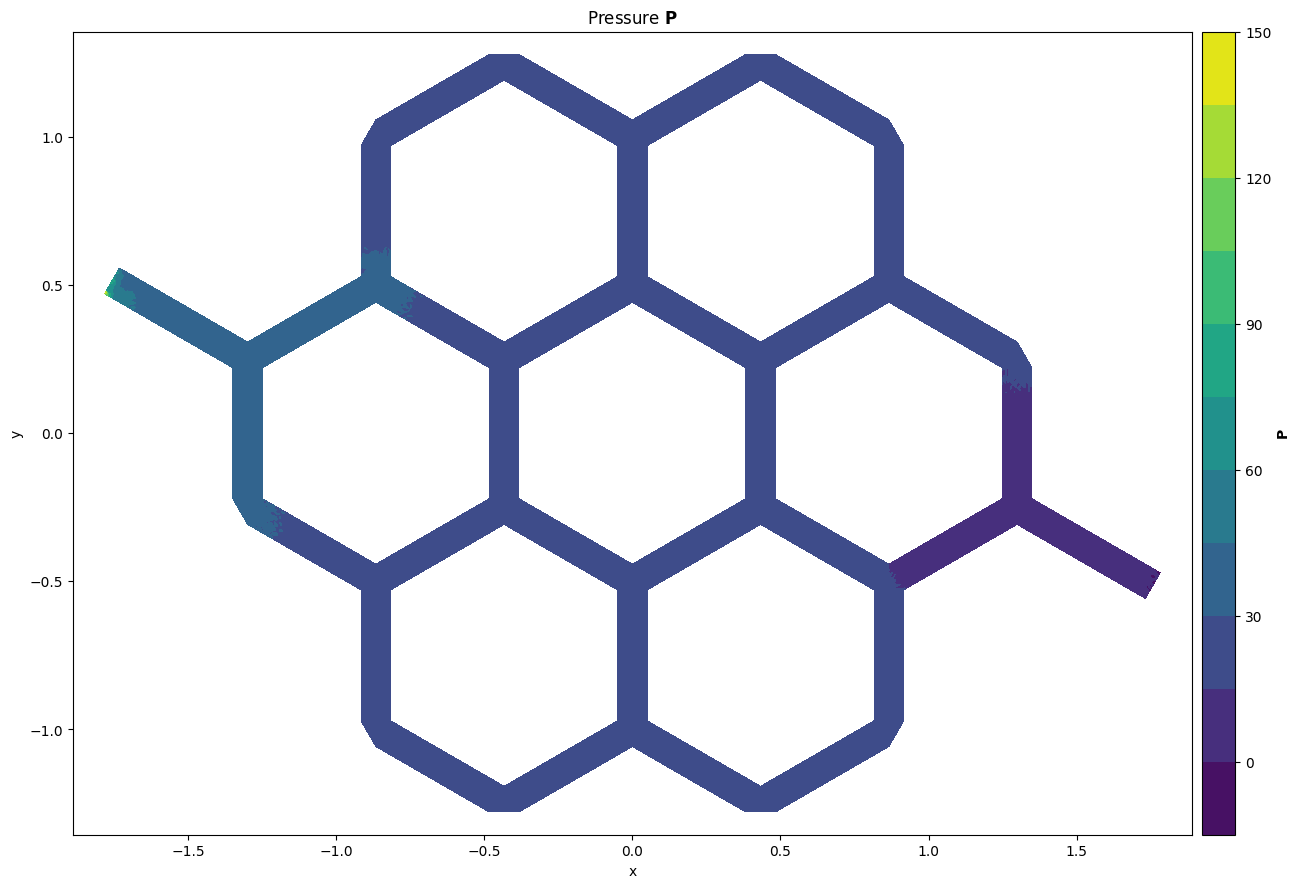

In [ ]:
plot_pressure(p_coarse, t_coarse, p_sol,
              levels=10,
              figsize=(14,14))